# Param Shah
## 240905320
## CSE-D 33
### Lab 3: PCA Machine Learning Algorithm

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Q1) Consider the hepatitis/ pima-indians-diabetes csv file, perform the following date pre-processing. 
1. Load data in Pandas. 
2. Drop columns that aren’t useful. 
3. Drop rows with missing values. 
4. Create dummy variables. 
5. Take care of missing data. 
6. Convert the data frame to NumPy. 
7. Divide the data set into training data and test data. 

In [17]:
df = pd.read_csv("hepatitis_csv.csv")

print("Original Data Shape:", df.shape)

df = df.drop(columns=['protime'], errors='ignore')

df = df.dropna()

print("After dropping missing rows:", df.shape)

df = pd.get_dummies(df, drop_first=True)

df = df.fillna(df.mean(numeric_only=True))

data = df.to_numpy()

np.random.seed(0)
indices = np.random.permutation(len(data))

split_index = int(0.8 * len(data))

train_idx = indices[:split_index]
test_idx = indices[split_index:]

train_data = data[train_idx]
test_data = data[test_idx]

X_train = train_data[:, :-1]
y_train = train_data[:, -1]

X_test = test_data[:, :-1]
y_test = test_data[:, -1]

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Original Data Shape: (155, 20)
After dropping missing rows: (112, 19)
Training Data Shape: (89, 18)
Testing Data Shape: (23, 18)


Q2) a.  Construct a CSV file with the following attributes: \
Study time in hours of ML lab course (x)\
Score out of 10 (y) \
The dataset should contain 10 rows. 

   b.  Create a regression model and display the following: \
Coefficients: B0 (intercept) and B1 (slope) \
RMSE (Root Mean Square Error) \
Predicted responses 

  c.  Create a scatter plot of the data points in red color and plot the graph of x vs. predicted y in blue color. 

  d.  Implement the model using two methods: 
Pedhazur formula (intuitive) \
Calculus method (partial derivatives, refer to class notes) 

 e.  Compare the coefficients obtained using both methods and compare them with the analytical solution. 
 
 f. Test your model to predict the score obtained when the study time of a student is 10 hours.

----- Pedhazur Method -----
B0 (Intercept): 1.396415382479523
B1 (Slope): 0.6884131611828405
RMSE: 0.7090789005624949

----- Gradient Descent -----
B0: 1.2729383737348203
B1: 0.7017729818767438

----- Comparison -----
Pedhazur B0: 1.396415382479523 | GD B0: 1.2729383737348203
Pedhazur B1: 0.6884131611828405 | GD B1: 0.7017729818767438

Predicted score for 10 hours: 8.280546994307928


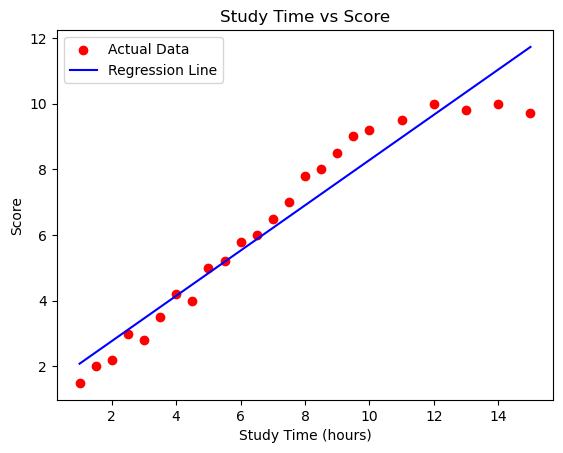

In [19]:
df = pd.read_csv("studyhours_marks.csv")

x = df["StudyTime"].values
y = df["Score"].values
n = len(x)

x_mean = np.mean(x)
y_mean = np.mean(y)

B1 = np.sum((x - x_mean)*(y - y_mean)) / np.sum((x - x_mean)**2)
B0 = y_mean - B1 * x_mean

y_pred = B0 + B1 * x

rmse = np.sqrt(np.mean((y - y_pred)**2))

print("----- Pedhazur Method -----")
print("B0 (Intercept):", B0)
print("B1 (Slope):", B1)
print("RMSE:", rmse)

B0_gd = 0
B1_gd = 0
lr = 0.001
epochs = 5000

for _ in range(epochs):
    y_pred_gd = B0_gd + B1_gd * x
    
    dB0 = (-2/n) * np.sum(y - y_pred_gd)
    dB1 = (-2/n) * np.sum((y - y_pred_gd) * x)

    B0_gd -= lr * dB0
    B1_gd -= lr * dB1

print("\n----- Gradient Descent -----")
print("B0:", B0_gd)
print("B1:", B1_gd)

print("\n----- Comparison -----")
print("Pedhazur B0:", B0, "| GD B0:", B0_gd)
print("Pedhazur B1:", B1, "| GD B1:", B1_gd)

test_val = 10
predicted_score = B0 + B1 * test_val
print("\nPredicted score for 10 hours:", predicted_score)

plt.scatter(x, y, color='red', label='Actual Data')
plt.plot(x, y_pred, color='blue', label='Regression Line')
plt.xlabel("Study Time (hours)")
plt.ylabel("Score")
plt.title("Study Time vs Score")
plt.legend()
plt.show()